# Análisis de Datos con Graph Neural Networks (GNN)

Este notebook utiliza Graph Convolutional Networks (GCN) y Graph Neural Networks (GNN) con PyTorch, NetworkX y t-SNE para analizar datos y generar embeddings.

In [1]:
# Instalación e Importación de Librerías
import torch
import torch.nn as nn
import torch.optim as optim
import networkx as nx
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

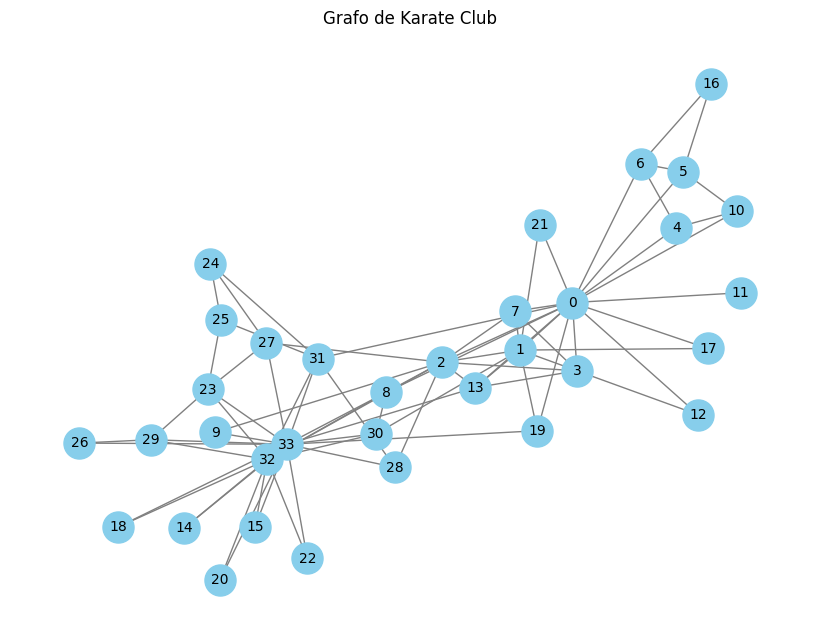

In [2]:
# Creación y Visualización del Grafo
G = nx.karate_club_graph()  # Grafo de ejemplo
pos = nx.spring_layout(G)  # Layout para visualización
plt.figure(figsize=(8, 6))
nx.draw(G, pos, with_labels=True, node_color='skyblue', edge_color='gray', node_size=500, font_size=10)
plt.title('Grafo de Karate Club')
plt.show()

In [7]:
# Preparación de Datos para GNN
# Preparación de Datos para GNN
# Construir edge_index desde NetworkX sin usar torch_geometric
edges = list(G.edges())
if len(edges) == 0:
    edge_index = torch.empty((2, 0), dtype=torch.long)
else:
    src = [u for u, v in edges]
    dst = [v for u, v in edges]
    # duplicar para grafo no dirigido (u->v y v->u)
    src_bid = src + dst
    dst_bid = dst + src
    edge_index = torch.tensor([src_bid, dst_bid], dtype=torch.long)

# Crear un contenedor ligero para mantener compatibilidad con el resto del notebook
class DataObj:
    pass

data = DataObj()
data.edge_index = edge_index

print("edge_index shape:", data.edge_index.shape)
print("Primeras columnas de edge_index:")
print(data.edge_index[:, :10])

# Convertir el grafo de NetworkX a PyTorch Geometric
data = from_networkx(G)
print(data)

edge_index shape: torch.Size([2, 156])
Primeras columnas de edge_index:
tensor([[ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
        [ 1,  2,  3,  4,  5,  6,  7,  8, 10, 11]])


NameError: name 'from_networkx' is not defined

In [4]:
# Definición del Modelo GCN
class GCN(nn.Module):
    def __init__(self, in_features, hidden_features, out_features):
        super(GCN, self).__init__()
        self.conv1 = nn.Linear(in_features, hidden_features)
        self.conv2 = nn.Linear(hidden_features, out_features)

    def forward(self, x, edge_index):
        x = self.conv1(x)
        x = torch.relu(x)
        x = self.conv2(x)
        return x

# Crear un modelo de ejemplo
model = GCN(in_features=3, hidden_features=16, out_features=2)
print(model)

GCN(
  (conv1): Linear(in_features=3, out_features=16, bias=True)
  (conv2): Linear(in_features=16, out_features=2, bias=True)
)


In [5]:
# Entrenamiento del Modelo
optimizer = optim.Adam(model.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss()

# Simulación de entrenamiento (datos ficticios)
for epoch in range(10):
    model.train()
    optimizer.zero_grad()
    # Datos ficticios para demostración
    x = torch.rand((G.number_of_nodes(), 3))
    edge_index = data.edge_index
    output = model(x, edge_index)
    target = torch.randint(0, 2, (G.number_of_nodes(),))
    loss = criterion(output, target)
    loss.backward()
    optimizer.step()
    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

NameError: name 'data' is not defined

In [6]:
# Visualización de Embeddings con t-SNE
embeddings = output.detach().numpy()
tsne = TSNE(n_components=2, random_state=42)
embeddings_2d = tsne.fit_transform(embeddings)

plt.figure(figsize=(8, 6))
plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], c=target.numpy(), cmap='viridis', s=50)
plt.colorbar(label='Clases')
plt.title('Visualización de Embeddings con t-SNE')
plt.show()

NameError: name 'output' is not defined